# CNN básica con espectros excellent_unoriented

Primera aproximación del proyecto. Utiliza únicamente el dominio de mayor calidad (archivos excellent unoriented) y una partición simple por espectro. Sirve para mostrar el rendimiento inicial y, sobre todo, por qué una separación que no controla la fuente física puede producir una estimación demasiado optimista. 

Utiliza una CNN de prueba, que se irá refinando conforme al progreso del proyecto.

No considera restricciones estrictas sobre el conjunto de datos.

## Lugar dentro de la progresión experimental

Este notebook se conserva como evidencia de desarrollo y comparación. Debe ejecutarse desde un kernel limpio para generar sus resultados; no contiene métricas heredadas. Su propósito es mostrar qué problema metodológico se identifica en esta etapa y cómo conduce al siguiente experimento. Los resultados finales del TFM proceden de los notebooks con split fijo y cinco semillas.


Este notebook lee los TXT directamente desde los ZIP y muestra resultados inline. No exporta archivos ni crea carpetas de resultados.

## Importaciones y reproducibilidad

Se cargan las bibliotecas necesarias y se fijan las semillas aleatorias disponibles. La celda también informa de las versiones principales y de la disponibilidad de GPU. Fijar semillas reduce variaciones accidentales, aunque una única ejecución todavía no permite medir toda la variabilidad del entrenamiento; esa limitación se resuelve posteriormente en los notebooks finales de cinco semillas.


In [1]:
import os, re, json, random, zipfile, platform, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.interpolate import interp1d
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    log_loss, accuracy_score, top_k_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Devices:", tf.config.list_physical_devices())
print("✓ Reproducibility configured")
# Modo solo pantalla: no se escriben resultados en disco.
def _mostrar_en_pantalla(obj, destino=None, *args, **kwargs):
    nombre = str(destino) if destino is not None else "salida tabular"
    print(f"\n[SOLO PANTALLA] {nombre} | dimensiones: {getattr(obj, 'shape', None)}")
    try:
        display(obj if len(obj) <= 40 else obj.head(40))
    except Exception:
        print(obj)

pd.DataFrame.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
pd.Series.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
np.save = lambda destino, datos, *a, **k: _mostrar_en_pantalla(pd.DataFrame(np.atleast_1d(datos)), destino)
plt.savefig = lambda destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
from matplotlib.figure import Figure
Figure.savefig = lambda self, destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
Path.write_text = lambda self, data, *a, **k: print(f"[SOLO PANTALLA] {self.name}:\n{str(data)[:4000]}") or len(str(data))

class ZipMember:
    """Referencia ligera a un TXT dentro de un ZIP, sin extracción a disco."""
    def __init__(self, archive_path, member):
        self.archive_path, self.member = Path(archive_path), member
    @property
    def name(self): return Path(self.member).name
    def read_bytes(self):
        with zipfile.ZipFile(self.archive_path) as zf: return zf.read(self.member)
    def __str__(self): return f"{self.archive_path.name}::{self.member}"
    def __repr__(self): return str(self)

def open_spectrum(member):
    import io
    return io.StringIO(member.read_bytes().decode("utf-8", errors="replace"))


Python: 3.11.15
TensorFlow: 2.21.0
NumPy: 2.4.6
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✓ Reproducibility configured


## Configuración del experimento

Aquí se concentran las rutas, criterios mínimos de inclusión, tamaño de la cuadrícula Raman y parámetros de entrenamiento. Separar la configuración de la lógica facilita la reproducibilidad y permite identificar qué cambia entre etapas. Los umbrales no deben ajustarse mirando el test: cualquier decisión de diseño debe tomarse con información de entrenamiento y validación.


In [2]:
ZIP_FILENAME = "excellent_unoriented.zip"
ZIP_PATH = None  # Example: "/content/excellent_unoriented.zip"; None = search automatically

WORK_DIR = Path("raman_basic_experiment")
EXTRACT_DIR = WORK_DIR / "excellent_unoriented"
RESULTS_DIR = WORK_DIR / "results"

MIN_CLASS_COUNT = 5
N_GRID_POINTS = 512
COVERAGE_FRACTION = 0.95
MAX_EPOCHS = 150
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 15
LR_PATIENCE = 6


config = {k: v for k, v in {
    "seed": SEED, "zip_filename": ZIP_FILENAME,
    "min_class_count": MIN_CLASS_COUNT, "n_grid_points": N_GRID_POINTS,
    "coverage_fraction": COVERAGE_FRACTION, "max_epochs": MAX_EPOCHS,
    "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "lr_patience": LR_PATIENCE,
}.items()}
(RESULTS_DIR / "config.json").write_text(json.dumps(config, indent=2))
print("✓ Configuración mostrada en pantalla")


[SOLO PANTALLA] config.json:
{
  "seed": 42,
  "zip_filename": "excellent_unoriented.zip",
  "min_class_count": 5,
  "n_grid_points": 512,
  "coverage_fraction": 0.95,
  "max_epochs": 150,
  "batch_size": 32,
  "learning_rate": 0.001,
  "early_stopping_patience": 15,
  "lr_patience": 6
}
✓ Configuración mostrada en pantalla


## Localización y extracción de los datos

La celda busca únicamente los archivos previstos por el experimento y los extrae en directorios controlados. Esta comprobación evita mezclar accidentalmente versiones o dominios de RRUFF. La procedencia de cada espectro se conserva en el manifiesto para que pueda auditarse en las etapas posteriores.


In [3]:
def resolve_zip():
    if ZIP_PATH is not None:
        candidates = [Path(ZIP_PATH)]
    else:
        candidates = [Path.cwd() / ZIP_FILENAME, Path("/content") / ZIP_FILENAME]
    matches = [p.resolve() for p in candidates if p.exists()]
    if not matches:
        raise FileNotFoundError(
            f"Could not find {ZIP_FILENAME}. Put it beside the notebook, upload it to /content, "
            "or set ZIP_PATH to its full path."
        )
    return matches[0]

zip_path = resolve_zip()
if zip_path.name.lower() != ZIP_FILENAME.lower():
    raise ValueError(f"Expected only {ZIP_FILENAME}, received {zip_path.name}")

with zipfile.ZipFile(zip_path) as archive:
    members = sorted(n for n in archive.namelist() if n.lower().endswith(".txt"))
filepaths = [ZipMember(zip_path, member) for member in members]
if not filepaths:
    raise RuntimeError("The archive contains no .txt spectra.")
print("Archive:", zip_path)
print("Text files found:", len(filepaths))
print("✓ ZIP leído directamente, sin extracción")


Archive: /Users/nico/anaconda_projects/TFM - FINAL/excellent_unoriented.zip
Text files found: 11415
✓ ZIP leído directamente, sin extracción


## Lectura de espectros y construcción del manifiesto

Los archivos RRUFF pueden contener metadatos y separadores heterogéneos. El parser identifica pares numéricos de desplazamiento Raman e intensidad, ordena el eje y descarta registros que no permiten construir un espectro válido. El manifiesto conserva etiqueta, archivo, dominio e identificador de fuente cuando está disponible, proporcionando trazabilidad desde la predicción hasta el fichero original.


In [4]:
NUMBER = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][-+]?\d+)?")

def mineral_from_filename(path):
    label = path.name.split("__")[0].strip()
    return label.replace("_", " ")

def load_spectrum(path):
    pairs = []
    try:
        with open_spectrum(path) as handle:
            for line in handle:
                if not line.strip() or line.lstrip().startswith("##"):
                    continue
                values = NUMBER.findall(line)
                if len(values) >= 2:
                    try:
                        pairs.append((float(values[0]), float(values[1])))
                    except ValueError:
                        pass
        if len(pairs) < 10:
            return None, "fewer than 10 numeric pairs"
        arr = np.asarray(pairs, dtype=np.float64)
        finite_x = np.isfinite(arr[:, 0])
        arr = arr[finite_x]
        if len(arr) < 10:
            return None, "too few finite Raman coordinates"
        finite_y = np.isfinite(arr[:, 1])
        if not finite_y.all():
            return None, "non-finite intensities"
        frame = pd.DataFrame({"shift": arr[:, 0], "intensity": arr[:, 1]})
        frame = frame.groupby("shift", as_index=False)["intensity"].mean().sort_values("shift")
        if len(frame) < 10 or frame["shift"].iloc[-1] <= frame["shift"].iloc[0]:
            return None, "degenerate Raman axis"
        if np.max(np.abs(frame["intensity"].to_numpy())) <= 1e-12:
            return None, "flat or effectively zero spectrum"
        return (frame["shift"].to_numpy(), frame["intensity"].to_numpy()), None
    except Exception as exc:
        return None, f"parse error: {type(exc).__name__}"

records, parsed = [], {}
for i, path in enumerate(filepaths):
    result, reason = load_spectrum(path)
    label = mineral_from_filename(path)
    record = {
        "spectrum_id": f"S{i:06d}", "filepath": str(path), "filename": path.name,
        "label": label, "accepted_parse": result is not None, "rejection_reason": reason,
    }
    if result is not None:
        shift, intensity = result
        record.update(n_points=len(shift), min_shift=float(shift.min()), max_shift=float(shift.max()))
        parsed[record["spectrum_id"]] = (shift, intensity)
    records.append(record)

manifest = pd.DataFrame(records)
manifest.to_csv(RESULTS_DIR / "parsing_manifest.csv", index=False)
print("Files parsed successfully:", int(manifest["accepted_parse"].sum()))
print("Files rejected during parsing:", int((~manifest["accepted_parse"]).sum()))
display(manifest.loc[~manifest["accepted_parse"], "rejection_reason"].value_counts().rename("count").to_frame())
print("✓ Parsing manifest saved")



[SOLO PANTALLA] raman_basic_experiment/results/parsing_manifest.csv | dimensiones: (11415, 9)


,spectrum_id,filepath,filename,label,accepted_parse,rejection_reason,n_points,min_shift,max_shift
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,Abellaite,True,None,3209,50.00000,1301.270
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,Abellaite,True,None,3209,50.00000,1301.270
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,True,None,2312,153.55700,1267.727
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,True,None,2379,153.55700,1300.029
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,True,None,2367,163.43140,1304.119
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,True,None,2515,92.07813,1304.119
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,True,None,2476,91.82715,1285.066
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,True,None,2476,91.82715,1285.066
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,True,None,1077,139.24300,1513.235
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,True,None,1077,139.24300,1513.235


Files parsed successfully: 11415
Files rejected during parsing: 0


,count
rejection_reason,


✓ Parsing manifest saved


## Lectura de espectros y construcción del manifiesto

Los archivos RRUFF pueden contener metadatos y separadores heterogéneos. El parser identifica pares numéricos de desplazamiento Raman e intensidad, ordena el eje y descarta registros que no permiten construir un espectro válido. El manifiesto conserva etiqueta, archivo, dominio e identificador de fuente cuando está disponible, proporcionando trazabilidad desde la predicción hasta el fichero original.


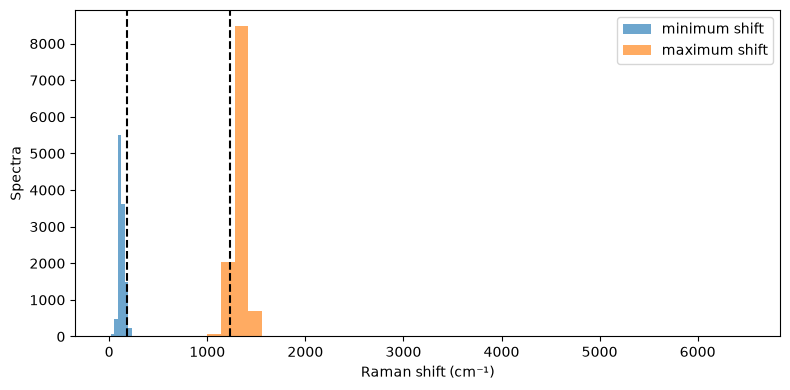

Selected interval: 180.71–1236.15 cm⁻¹
Grid: 512 points; spacing 2.065 cm⁻¹
Spectra with complete coverage: 10299


In [5]:
ok = manifest[manifest["accepted_parse"]].copy()
LOWER_LIMIT = float(np.quantile(ok["min_shift"], COVERAGE_FRACTION))
UPPER_LIMIT = float(np.quantile(ok["max_shift"], 1 - COVERAGE_FRACTION))
if LOWER_LIMIT >= UPPER_LIMIT:
    raise RuntimeError("No valid common Raman interval was found. Inspect the coverage plot and data files.")
target_grid = np.linspace(LOWER_LIMIT, UPPER_LIMIT, N_GRID_POINTS, dtype=np.float32)

coverage_ok = (ok["min_shift"] <= LOWER_LIMIT) & (ok["max_shift"] >= UPPER_LIMIT)
coverage_ids = set(ok.loc[coverage_ok, "spectrum_id"])
manifest["accepted_coverage"] = manifest["spectrum_id"].isin(coverage_ids)
mask = manifest["accepted_parse"] & ~manifest["accepted_coverage"]
manifest.loc[mask, "rejection_reason"] = "insufficient common-interval coverage"

plt.figure(figsize=(8, 4))
plt.hist(ok["min_shift"], bins=40, alpha=0.65, label="minimum shift")
plt.hist(ok["max_shift"], bins=40, alpha=0.65, label="maximum shift")
plt.axvline(LOWER_LIMIT, color="black", linestyle="--")
plt.axvline(UPPER_LIMIT, color="black", linestyle="--")
plt.xlabel("Raman shift (cm⁻¹)"); plt.ylabel("Spectra"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Selected interval: {LOWER_LIMIT:.2f}–{UPPER_LIMIT:.2f} cm⁻¹")
print(f"Grid: {N_GRID_POINTS} points; spacing {target_grid[1]-target_grid[0]:.3f} cm⁻¹")
print("Spectra with complete coverage:", len(coverage_ids))


## Armonización, normalización y filtrado de clases

Cada espectro aceptado se interpola linealmente solo dentro de su rango medido y se normaliza por su intensidad absoluta máxima. Después se aplican los requisitos mínimos de observaciones y, cuando corresponde, de fuentes independientes. Las clases excluidas no disponen de evidencia suficiente para formar particiones evaluables de manera fiable.


In [6]:
X_list, labels, metadata_rows = [], [], []
for row in manifest[manifest["accepted_coverage"]].itertuples():
    shift, intensity = parsed[row.spectrum_id]
    interpolated = np.interp(target_grid, shift, intensity).astype(np.float32)
    scale = float(np.max(np.abs(interpolated)))
    if not np.isfinite(scale) or scale <= 1e-12:
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "accepted_coverage"] = False
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "rejection_reason"] = "invalid normalization divisor"
        continue
    normalized = (interpolated / scale).astype(np.float32)
    if not np.isfinite(normalized).all():
        raise AssertionError(f"Non-finite normalized values in {row.filepath}")
    X_list.append(normalized); labels.append(row.label)
    metadata_rows.append({"spectrum_id": row.spectrum_id, "filepath": row.filepath, "label": row.label})

X_all = np.asarray(X_list, dtype=np.float32)
metadata = pd.DataFrame(metadata_rows)
class_counts_before = metadata["label"].value_counts()
valid_classes = set(class_counts_before[class_counts_before >= MIN_CLASS_COUNT].index)
keep = metadata["label"].isin(valid_classes).to_numpy()
X = X_all[keep]
metadata = metadata.loc[keep].reset_index(drop=True)

encoder = LabelEncoder()
y = encoder.fit_transform(metadata["label"]).astype(np.int32)
class_names = encoder.classes_
n_classes = len(class_names)
X_cnn = X[..., np.newaxis].astype(np.float32)

assert len(X_cnn) == len(y) == len(metadata)
assert X_cnn.shape == (len(X), N_GRID_POINTS, 1)
assert X_cnn.dtype == np.float32 and np.isfinite(X_cnn).all()
assert n_classes == len(class_names)

manifest.to_csv(RESULTS_DIR / "final_manifest.csv", index=False)
class_counts_before.rename("usable_spectra").to_csv(RESULTS_DIR / "class_counts_before_filter.csv")
pd.DataFrame({"class_index": np.arange(n_classes), "label": class_names}).to_csv(RESULTS_DIR / "label_mapping.csv", index=False)

print("Usable spectra after class filtering:", len(X))
print("Retained classes:", n_classes)
print("Excluded classes:", int((class_counts_before < MIN_CLASS_COUNT).sum()))
print("✓ Harmonized float32 CNN input created")



[SOLO PANTALLA] raman_basic_experiment/results/final_manifest.csv | dimensiones: (11415, 10)


,spectrum_id,filepath,filename,label,accepted_parse,rejection_reason,n_points,min_shift,max_shift,accepted_coverage
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,Abellaite,True,None,3209,50.00000,1301.270,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,Abellaite,True,None,3209,50.00000,1301.270,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,True,None,2312,153.55700,1267.727,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,True,None,2379,153.55700,1300.029,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,True,None,2367,163.43140,1304.119,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,True,None,2515,92.07813,1304.119,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,True,None,2476,91.82715,1285.066,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,True,None,2476,91.82715,1285.066,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,True,None,1077,139.24300,1513.235,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,True,None,1077,139.24300,1513.235,True



[SOLO PANTALLA] raman_basic_experiment/results/class_counts_before_filter.csv | dimensiones: (1900,)


label
Grossular         74
Diamond           58
Andradite         54
Epidote           54
Calcite           52
Beryl             49
Forsterite        48
Pyrope            45
Diopside          42
Dolomite          42
Elbaite           41
Almandine         40
Wendwilsonite     40
Enstatite         38
Muscovite         38
Quartz            38
Anorthite         37
Fluorapatite      37
Albite            35
Marialite         35
Natrolite         34
Topaz             34
Actinolite        33
Cerussite         30
Tremolite         29
Spessartine       28
Corundum          27
Microcline        27
Cordierite        26
Sodalite          26
Triphylite        26
Triplite          26
Vivianite         26
Aegirine          25
Spinel            25
Axinite-(Fe)      24
Metatorbernite    24
Orthoclase        24
Rhodochrosite     24
Stibnite          24
Name: usable_spectra, dtype: int64


[SOLO PANTALLA] raman_basic_experiment/results/label_mapping.csv | dimensiones: (591, 2)


,class_index,label
0,0,Actinolite
1,1,Adamite
2,2,Adelite
3,3,Aegirine
4,4,Aenigmatite
5,5,Afghanite
6,6,Afwillite
7,7,Agardite-(Y)
8,8,Akermanite
9,9,Alacranite


Usable spectra after class filtering: 6503
Retained classes: 591
Excluded classes: 1309
✓ Harmonized float32 CNN input created


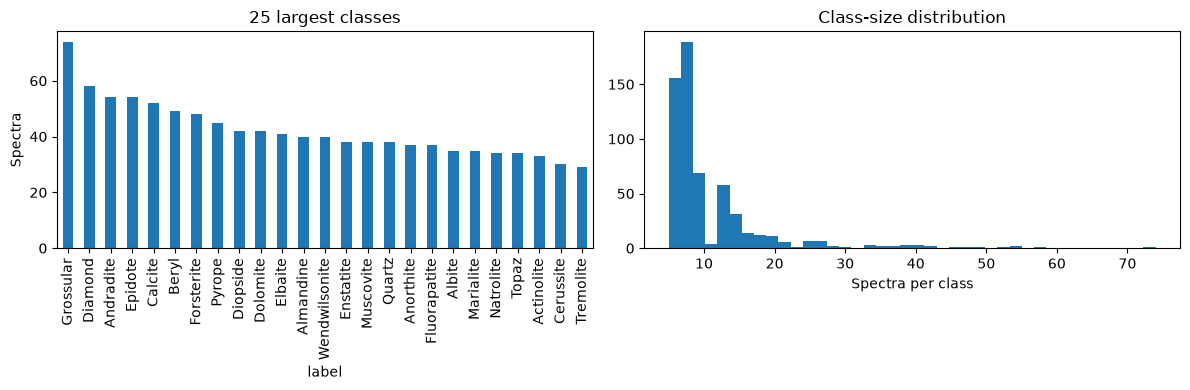

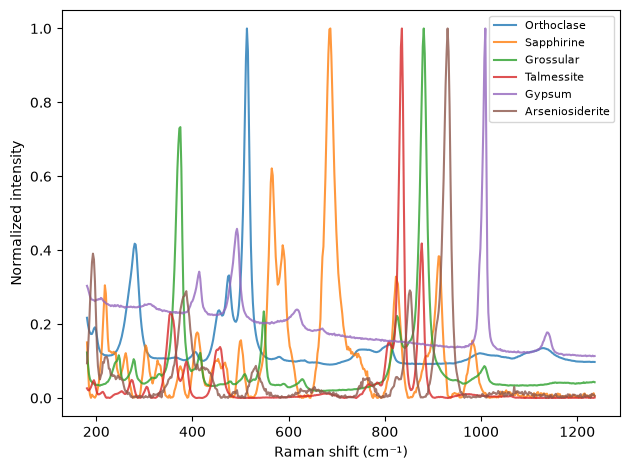

In [7]:
counts = metadata["label"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.head(25).plot.bar(ax=axes[0]); axes[0].set_title("25 largest classes"); axes[0].set_ylabel("Spectra")
axes[1].hist(counts.values, bins=40); axes[1].set_title("Class-size distribution"); axes[1].set_xlabel("Spectra per class")
plt.tight_layout(); plt.show()

rng = np.random.default_rng(SEED)
for idx in rng.choice(len(X), size=min(6, len(X)), replace=False):
    plt.plot(target_grid, X[idx], alpha=0.8, label=metadata.loc[idx, "label"])
plt.xlabel("Raman shift (cm⁻¹)"); plt.ylabel("Normalized intensity")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## Construcción de entrenamiento, validación y prueba

Entrenamiento se utiliza para ajustar los pesos; validación controla la parada temprana y la selección del checkpoint; test permanece intacto hasta la evaluación final. En las versiones `group-aware`, todas las mediciones asociadas a una misma fuente RRUFF permanecen en una sola partición. Así se evita que réplicas o mediciones estrechamente relacionadas aparezcan a ambos lados de la evaluación.


In [8]:
def classwise_split(y, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for cls in np.unique(y):
        idx = np.flatnonzero(y == cls).copy()
        rng.shuffle(idx)
        test_idx.append(int(idx[0])); val_idx.append(int(idx[1])); train_idx.extend(idx[2:].tolist())
    return tuple(np.asarray(sorted(v), dtype=np.int64) for v in (train_idx, val_idx, test_idx))

train_idx, val_idx, test_idx = classwise_split(y, SEED)
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)
assert len(train_idx) + len(val_idx) + len(test_idx) == len(y)
assert set(np.unique(y[train_idx])) == set(np.unique(y[val_idx])) == set(np.unique(y[test_idx]))

X_train, y_train = X_cnn[train_idx], y[train_idx]
X_val, y_val = X_cnn[val_idx], y[val_idx]
X_test, y_test = X_cnn[test_idx], y[test_idx]

split_name = np.full(len(y), "", dtype=object)
split_name[train_idx] = "train"; split_name[val_idx] = "validation"; split_name[test_idx] = "test"
split_manifest = metadata.copy(); split_manifest["class_index"] = y; split_manifest["partition"] = split_name
split_manifest.to_csv(RESULTS_DIR / "split_manifest.csv", index=False)
np.save(RESULTS_DIR / "train_indices.npy", train_idx)
np.save(RESULTS_DIR / "validation_indices.npy", val_idx)
np.save(RESULTS_DIR / "test_indices.npy", test_idx)

print(f"Training: {len(train_idx)} | Validation: {len(val_idx)} | Test: {len(test_idx)}")
print("Each validation and test class has exactly one spectrum.")
print("⚠ Source-level independence is not guaranteed.")
print("✓ Partitions created before model training")



[SOLO PANTALLA] raman_basic_experiment/results/split_manifest.csv | dimensiones: (6503, 5)


,spectrum_id,filepath,label,class_index,partition
0,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite,0,train
1,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite,0,train
2,S000010,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite,0,train
3,S000011,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite,0,train
4,S000012,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite,0,train
5,S000013,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite,0,train
6,S000014,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite,0,train
7,S000015,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite,0,train
8,S000016,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite,0,train
9,S000017,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite,0,train



[SOLO PANTALLA] raman_basic_experiment/results/train_indices.npy | dimensiones: (5321, 1)


,0
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7
8,8
9,9



[SOLO PANTALLA] raman_basic_experiment/results/validation_indices.npy | dimensiones: (591, 1)


,0
0,18
1,35
2,46
3,69
4,82
5,86
6,91
7,106
8,112
9,115



[SOLO PANTALLA] raman_basic_experiment/results/test_indices.npy | dimensiones: (591, 1)


,0
0,10
1,42
2,45
3,58
4,77
5,87
6,90
7,103
8,111
9,116


Training: 5321 | Validation: 591 | Test: 591
Each validation and test class has exactly one spectrum.
⚠ Source-level independence is not guaranteed.
✓ Partitions created before model training


## Pesos de clase calculados con entrenamiento

Los pesos compensan parcialmente el desbalance, dando más importancia a clases escasas durante la optimización. Se calculan exclusivamente con las etiquetas originales de entrenamiento. Validación y test no participan en este cálculo, por lo que continúan representando datos no utilizados para ajustar el modelo.


In [9]:
weights = compute_class_weight(class_weight="balanced", classes=np.arange(n_classes), y=y_train)
class_weight_dict = {int(i): float(w) for i, w in enumerate(weights)}
(RESULTS_DIR / "class_weights.json").write_text(json.dumps(class_weight_dict, indent=2))
print("Weight range:", f"{weights.min():.3f}–{weights.max():.3f}")
print("✓ Training-only class weights calculated")


[SOLO PANTALLA] class_weights.json:
{
  "0": 0.29043174499208557,
  "1": 0.9003384094754653,
  "2": 1.8006768189509306,
  "3": 0.3914514823806371,
  "4": 2.250846023688663,
  "5": 1.8006768189509306,
  "6": 1.5005640157924423,
  "7": 1.1254230118443316,
  "8": 2.250846023688663,
  "9": 2.250846023688663,
  "10": 0.27282982105317133,
  "11": 1.5005640157924423,
  "12": 2.250846023688663,
  "13": 0.5296108291032149,
  "14": 0.23693116038828035,
  "15": 1.5005640157924423,
  "16": 0.7502820078962211,
  "17": 2.250846023688663,
  "18": 1.5005640157924423,
  "19": 1.5005640157924423,
  "20": 1.5005640157924423,
  "21": 1.5005640157924423,
  "22": 0.5627115059221658,
  "23": 1.5005640157924423,
  "24": 0.6925680072888195,
  "25": 0.45016920473773264,
  "26": 0.17314200182220488,
  "27": 0.5627115059221658,
  "28": 0.7502820078962211,
  "29": 0.9003384094754653,
  "30": 1.5005640157924423,
  "31": 2.250846023688663,
  "32": 0.25723954556441864,
  "33": 2.250846023688663,
  "34": 2.25084602368

## Arquitectura de la CNN 1D

La entrada es el espectro normalizado completo. Las convoluciones aprenden patrones locales asociados a picos y vecindades espectrales; el pooling reduce la resolución y el coste; las capas finales integran la información y la salida softmax asigna una probabilidad a cada clase mineral. Esta etapa conserva la arquitectura de referencia para que los cambios de rendimiento puedan atribuirse principalmente al protocolo de datos.


In [10]:
def build_model(input_shape, n_classes):
    inputs = tf.keras.Input(shape=input_shape, name="spectrum")
    x = inputs
    for filters, kernel in [(32, 11), (64, 7), (128, 5)]:
        x = tf.keras.layers.Conv1D(filters, kernel, padding="same", use_bias=False, kernel_initializer="he_normal")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(256, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(256, activation="relu", kernel_initializer="he_normal")(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="class_probabilities")(x)
    return tf.keras.Model(inputs, outputs, name="basic_raman_cnn")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
model = build_model((N_GRID_POINTS, 1), n_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, n_classes), name="top_5_accuracy"),
    ],
)
assert model.output_shape[-1] == n_classes
model.summary()

sample_output = model(X_train[:2], training=False).numpy()
assert sample_output.shape == (2, n_classes)
assert np.allclose(sample_output.sum(axis=1), 1.0, atol=1e-5)
print("✓ Model and two-spectrum forward pass verified")


Model: "basic_raman_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectrum (InputLayer)           │ (None, 512, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 512, 32)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 64)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 128)       │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 591)            │       151,887 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,783 (1.42 MB)

 Trainable params: 372,335 (1.42 MB)

 Non-trainable params: 448 (1.75 KB)

✓ Model and two-spectrum forward pass verified


## Entrenamiento del modelo

El modelo se ajusta únicamente con entrenamiento. La pérdida de validación determina la reducción de la tasa de aprendizaje, la parada temprana y la restauración del mejor checkpoint. El conjunto de prueba no se entrega a `fit` y no interviene en ninguna decisión de entrenamiento.


In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True, mode="min", verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=LR_PATIENCE,
        min_lr=1e-6, mode="min", verbose=1,
    ),
]

start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)
training_minutes = (time.time() - start) / 60
print(f"✓ Training completed in {training_minutes:.1f} minutes")


Epoch 1/150


E0000 00:00:1786577929.099613  479841 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0051 - loss: 6.4162 - top_5_accuracy: 0.0203

E0000 00:00:1786577946.192357  479841 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


167/167 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.0051 - loss: 6.4155 - top_5_accuracy: 0.0203 - val_accuracy: 0.0000e+00 - val_loss: 6.3727 - val_top_5_accuracy: 0.0051 - learning_rate: 0.0010
Epoch 2/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.0100 - loss: 6.2445 - top_5_accuracy: 0.0393 - val_accuracy: 0.0000e+00 - val_loss: 6.2892 - val_top_5_accuracy: 0.0085 - learning_rate: 0.0010
Epoch 3/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.0113 - loss: 6.0669 - top_5_accuracy: 0.0466 - val_accuracy: 0.0034 - val_loss: 6.1313 - val_top_5_accuracy: 0.0186 - learning_rate: 0.0010
Epoch 4/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.0118 - loss: 5.8485 - top_5_accuracy: 0.0545 - val_accuracy: 0.0118 - val_loss: 6.0236 - val_top_5_accuracy: 0.0305 - learning_rate: 0.0010
Epoch 5/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.0130 - loss: 5.6313 - top_5_accuracy: 0.0648 - val_accuracy: 0.0118 - val_loss: 6.0101 - val_top_5_

## Curvas de aprendizaje

Las curvas permiten comparar la evolución en entrenamiento y validación. Si la pérdida de entrenamiento continúa bajando mientras la de validación aumenta, existe evidencia de sobreajuste. También ayudan a comprobar si el entrenamiento terminó por convergencia o por alcanzar el límite de épocas.


[SOLO PANTALLA] Figura mostrada; no se guarda raman_basic_experiment/results/learning_curves.png


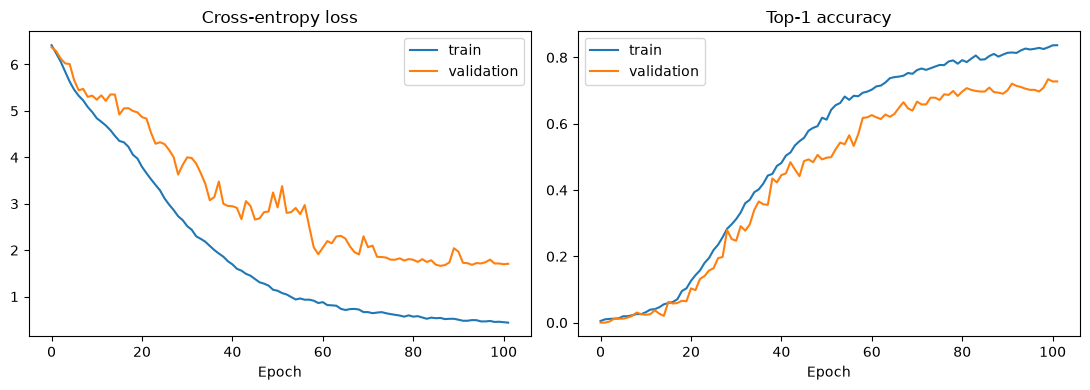

In [12]:
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df["loss"], label="train"); axes[0].plot(history_df["val_loss"], label="validation")
axes[0].set_title("Cross-entropy loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history_df["accuracy"], label="train"); axes[1].plot(history_df["val_accuracy"], label="validation")
axes[1].set_title("Top-1 accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / "learning_curves.png", dpi=160); plt.show()


## Evaluación final sobre test

Esta es la primera sección que utiliza el test. Top-1 exige que la clase más probable sea correcta; Top-3 y Top-5 comprueban si la clase real aparece entre las primeras alternativas. Precision, recall y F1 macro dan el mismo peso a cada mineral, mientras que sus versiones ponderadas reflejan la frecuencia de las clases. El test sirve para estimar generalización y nunca para escoger hiperparámetros.


In [13]:
test_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
assert test_prob.shape == (len(test_idx), n_classes)
assert np.allclose(test_prob.sum(axis=1), 1.0, atol=1e-5)
test_pred = test_prob.argmax(axis=1)

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_test, test_pred, average="macro", zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_test, test_pred, average="weighted", zero_division=0
)

metrics = {
    "test_cross_entropy": float(log_loss(y_test, test_prob, labels=np.arange(n_classes))),
    "top_1_accuracy": float(accuracy_score(y_test, test_pred)),
    "top_3_accuracy": float(top_k_accuracy_score(y_test, test_prob, k=min(3, n_classes), labels=np.arange(n_classes))),
    "top_5_accuracy": float(top_k_accuracy_score(y_test, test_prob, k=min(5, n_classes), labels=np.arange(n_classes))),
    "macro_precision": float(macro_p), "macro_recall": float(macro_r), "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_p), "weighted_recall": float(weighted_r), "weighted_f1": float(weighted_f1),
}
(RESULTS_DIR / "final_test_metrics.json").write_text(json.dumps(metrics, indent=2))
display(pd.Series(metrics, name="value").to_frame().style.format("{:.4f}"))

top_k = min(5, n_classes)
top_indices = np.argsort(-test_prob, axis=1)[:, :top_k]
predictions = split_manifest.iloc[test_idx][["spectrum_id", "filepath", "label"]].reset_index(drop=True)
predictions["predicted_label"] = class_names[test_pred]
predictions["correct"] = test_pred == y_test
predictions["top_5_labels"] = [" | ".join(class_names[row]) for row in top_indices]
predictions["top_5_probabilities"] = [" | ".join(f"{test_prob[i,j]:.5f}" for j in row) for i, row in enumerate(top_indices)]
predictions.to_csv(RESULTS_DIR / "final_test_predictions.csv", index=False)

report = pd.DataFrame(classification_report(
    y_test, test_pred, labels=np.arange(n_classes), target_names=class_names,
    zero_division=0, output_dict=True,
)).T
report.to_csv(RESULTS_DIR / "classification_report.csv")
print("✓ Final test evaluated once and metrics saved")


E0000 00:00:1786579368.824431  479841 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


[SOLO PANTALLA] final_test_metrics.json:
{
  "test_cross_entropy": 1.6110656261444092,
  "top_1_accuracy": 0.7106598984771574,
  "top_3_accuracy": 0.8375634517766497,
  "top_5_accuracy": 0.8697123519458545,
  "macro_precision": 0.6346587704455724,
  "macro_recall": 0.7106598984771574,
  "macro_f1": 0.6586012408347434,
  "weighted_precision": 0.6346587704455724,
  "weighted_recall": 0.7106598984771574,
  "weighted_f1": 0.6586012408347434
}


,value
test_cross_entropy,1.6111
top_1_accuracy,0.7107
top_3_accuracy,0.8376
top_5_accuracy,0.8697
macro_precision,0.6347
macro_recall,0.7107
macro_f1,0.6586
weighted_precision,0.6347
weighted_recall,0.7107
weighted_f1,0.6586



[SOLO PANTALLA] raman_basic_experiment/results/final_test_predictions.csv | dimensiones: (591, 7)


,spectrum_id,filepath,label,predicted_label,correct,top_5_labels,top_5_probabilities
0,S000018,excellent_unoriented.zip::Actinolite__R050025_...,Actinolite,Actinolite,True,Actinolite | Tremolite | Brannockite | Szaibel...,0.83839 | 0.08819 | 0.07269 | 0.00022 | 0.00014
1,S000057,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Adamite,True,Adamite | Roselite | Forsterite | Hydroxylclin...,0.30766 | 0.28883 | 0.20737 | 0.16663 | 0.01681
2,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite,Leucite,False,Leucite | Kleinite | Armangite | Leucophoenici...,0.72642 | 0.09055 | 0.07322 | 0.02790 | 0.01899
3,S000077,excellent_unoriented.zip::Aegirine__R050074__R...,Aegirine,Vivianite,False,Vivianite | Sampleite | Marialite | Aegirine |...,0.30334 | 0.28059 | 0.10862 | 0.05243 | 0.03695
4,S000102,excellent_unoriented.zip::Aenigmatite__R061088...,Aenigmatite,Aenigmatite,True,Aenigmatite | Ilesite | Pargasite | Sincosite ...,0.76414 | 0.07934 | 0.03188 | 0.02448 | 0.02197
5,S000114,excellent_unoriented.zip::Afghanite__R070558__...,Afghanite,Anapaite,False,Anapaite | Marokite | Cinnabar | Riebeckite | ...,0.98759 | 0.00825 | 0.00249 | 0.00106 | 0.00023
6,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite,Sengierite,False,Sengierite | Sapphirine | Agardite-(Y) | Clino...,0.56687 | 0.18698 | 0.10489 | 0.03056 | 0.02845
7,S000135,excellent_unoriented.zip::Agardite-(Y)__R06092...,Agardite-(Y),Agardite-(Y),True,Agardite-(Y) | Adamite | Marialite | Pyrope | ...,0.82562 | 0.04921 | 0.03172 | 0.01518 | 0.01342
8,S000159,excellent_unoriented.zip::Akermanite__R061085_...,Akermanite,Akermanite,True,Akermanite | Cornwallite | Andradite | Enstati...,0.98661 | 0.00433 | 0.00231 | 0.00142 | 0.00131
9,S000175,excellent_unoriented.zip::Alacranite__R150030_...,Alacranite,Alacranite,True,Alacranite | Scheelite | Curite | Laurelite | ...,0.97697 | 0.00354 | 0.00309 | 0.00257 | 0.00239



[SOLO PANTALLA] raman_basic_experiment/results/classification_report.csv | dimensiones: (594, 4)


,precision,recall,f1-score,support
Actinolite,1.000000,1.0,1.000000,1.0
Adamite,1.000000,1.0,1.000000,1.0
Adelite,0.000000,0.0,0.000000,1.0
Aegirine,0.000000,0.0,0.000000,1.0
Aenigmatite,1.000000,1.0,1.000000,1.0
Afghanite,0.000000,0.0,0.000000,1.0
Afwillite,0.000000,0.0,0.000000,1.0
Agardite-(Y),0.500000,1.0,0.666667,1.0
Akermanite,1.000000,1.0,1.000000,1.0
Alacranite,1.000000,1.0,1.000000,1.0


✓ Final test evaluated once and metrics saved


## Análisis de errores y resumen del experimento

Se exportan la matriz de confusión y los pares de confusión más frecuentes, además de ejemplos de predicciones incorrectas. Con centenares de clases, una única figura completa es difícil de leer; las tablas permiten identificar minerales problemáticos y estudiar si comparten características espectrales. El resumen registra datos, particiones, configuración y métricas para facilitar comparaciones posteriores.


In [14]:
cm = confusion_matrix(y_test, test_pred, labels=np.arange(n_classes))
np.save(RESULTS_DIR / "confusion_matrix.npy", cm)

errors = predictions.loc[~predictions["correct"]].copy()
confusions = (errors.groupby(["label", "predicted_label"]).size()
              .rename("count").reset_index().sort_values("count", ascending=False))
confusions.to_csv(RESULTS_DIR / "frequent_confusions.csv", index=False)

print("Most frequent incorrect pairs:")
display(confusions.head(20))
print("Example errors:")
display(errors.head(15))

summary = {
    "archive": ZIP_FILENAME,
    "files_found": len(filepaths),
    "spectra_retained": len(X),
    "classes_retained": n_classes,
    "raman_interval_cm-1": [LOWER_LIMIT, UPPER_LIMIT],
    "grid_points": N_GRID_POINTS,
    "split": {"train": len(train_idx), "validation": len(val_idx), "test": len(test_idx)},
    "source_independence_guaranteed": False,
    "epochs_run": len(history_df),
    "training_minutes": training_minutes,
    "test_metrics": metrics,
}
(RESULTS_DIR / "experiment_summary.json").write_text(json.dumps(summary, indent=2))
print("\nResults directory:", RESULTS_DIR.resolve())
print("✓ Experiment complete")



[SOLO PANTALLA] raman_basic_experiment/results/confusion_matrix.npy | dimensiones: (591, 591)


,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,590
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0



[SOLO PANTALLA] raman_basic_experiment/results/frequent_confusions.csv | dimensiones: (171, 3)


,label,predicted_label,count
0,Adelite,Leucite,1
117,Retgersite,Starkeyite,1
109,Perovskite,Vigezzite,1
110,Polylithionite,Trilithionite,1
111,Proto-ferro-anthophyllite,Grunerite,1
112,Pseudomalachite,Vesuvianite,1
113,Pyroaurite,Coquimbite,1
114,Pyrochlore,Fluorcalciomicrolite,1
115,Pyrope,Pyrobelonite,1
116,Pyroxmangite,Argentopyrite,1


Most frequent incorrect pairs:


,label,predicted_label,count
0,Adelite,Leucite,1
117,Retgersite,Starkeyite,1
109,Perovskite,Vigezzite,1
110,Polylithionite,Trilithionite,1
111,Proto-ferro-anthophyllite,Grunerite,1
112,Pseudomalachite,Vesuvianite,1
113,Pyroaurite,Coquimbite,1
114,Pyrochlore,Fluorcalciomicrolite,1
115,Pyrope,Pyrobelonite,1
116,Pyroxmangite,Argentopyrite,1


Example errors:


,spectrum_id,filepath,label,predicted_label,correct,top_5_labels,top_5_probabilities
2,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite,Leucite,False,Leucite | Kleinite | Armangite | Leucophoenici...,0.72642 | 0.09055 | 0.07322 | 0.02790 | 0.01899
3,S000077,excellent_unoriented.zip::Aegirine__R050074__R...,Aegirine,Vivianite,False,Vivianite | Sampleite | Marialite | Aegirine |...,0.30334 | 0.28059 | 0.10862 | 0.05243 | 0.03695
5,S000114,excellent_unoriented.zip::Afghanite__R070558__...,Afghanite,Anapaite,False,Anapaite | Marokite | Cinnabar | Riebeckite | ...,0.98759 | 0.00825 | 0.00249 | 0.00106 | 0.00023
6,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite,Sengierite,False,Sengierite | Sapphirine | Agardite-(Y) | Clino...,0.56687 | 0.18698 | 0.10489 | 0.03056 | 0.02845
19,S000390,excellent_unoriented.zip::Amblygonite__R040067...,Amblygonite,Montebrasite,False,Montebrasite | Amblygonite | Scottyite | Natro...,0.95609 | 0.03551 | 0.00559 | 0.00091 | 0.00079
31,S000621,excellent_unoriented.zip::Annite__R060211__Ram...,Annite,Corkite,False,Corkite | Beudantite | Lefontite | Astrophylli...,0.50910 | 0.23867 | 0.06037 | 0.05275 | 0.04486
32,S000662,excellent_unoriented.zip::Anorthite__R070598__...,Anorthite,Yugawaralite,False,Yugawaralite | Braunite | Anorthite | Bikitait...,0.32763 | 0.27985 | 0.18229 | 0.08554 | 0.04913
33,S000683,excellent_unoriented.zip::Antimony__R070318__R...,Antimony,Dioptase,False,Dioptase | Diamond | Skutterudite | Fizelyite ...,0.71215 | 0.24441 | 0.02161 | 0.01951 | 0.00071
39,S000775,excellent_unoriented.zip::Armalcolite__R110187...,Armalcolite,Titanite,False,Titanite | Sewardite | Philipsbornite | Robert...,0.49471 | 0.26138 | 0.05677 | 0.04622 | 0.04585
46,S000872,excellent_unoriented.zip::Artesunate__D120023_...,Artesunate,Edenite,False,Edenite | Fizelyite | Magnesio-fluoro-hastings...,0.54431 | 0.36465 | 0.02161 | 0.01654 | 0.00637


[SOLO PANTALLA] experiment_summary.json:
{
  "archive": "excellent_unoriented.zip",
  "files_found": 11415,
  "spectra_retained": 6503,
  "classes_retained": 591,
  "raman_interval_cm-1": [
    180.709,
    1236.155
  ],
  "grid_points": 512,
  "split": {
    "train": 5321,
    "validation": 591,
    "test": 591
  },
  "source_independence_guaranteed": false,
  "epochs_run": 102,
  "training_minutes": 23.97688359816869,
  "test_metrics": {
    "test_cross_entropy": 1.6110656261444092,
    "top_1_accuracy": 0.7106598984771574,
    "top_3_accuracy": 0.8375634517766497,
    "top_5_accuracy": 0.8697123519458545,
    "macro_precision": 0.6346587704455724,
    "macro_recall": 0.7106598984771574,
    "macro_f1": 0.6586012408347434,
    "weighted_precision": 0.6346587704455724,
    "weighted_recall": 0.7106598984771574,
    "weighted_f1": 0.6586012408347434
  }
}

Results directory: /Users/nico/anaconda_projects/TFM - FINAL/raman_basic_experiment/results
✓ Experiment complete


## Comentarios

Entrenamiento se utiliza para ajustar los pesos; validación controla la parada temprana y la selección del checkpoint; test permanece intacto hasta la evaluación final. En las versiones `group-aware`, todas las mediciones asociadas a una misma fuente RRUFF permanecen en una sola partición. Así se evita que réplicas o mediciones estrechamente relacionadas aparezcan a ambos lados de la evaluación.
